In [1]:
import numpy as np 
import pandas as pd
import os

from PIL import Image
import itertools 
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set_style("darkgrid")
from sklearn.model_selection import train_test_split 
from sklearn.metrics import confusion_matrix , classification_report  

import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.optimizers import Adam , Adamax 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import warnings 
warnings.filterwarnings("ignore")

print("Done")

2026-06-06 10:11:54.714877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780740714.898111      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780740714.952199      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780740715.403824      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780740715.403867      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780740715.403870      23 computation_placer.cc:177] computation placer alr

Done


In [2]:
data_dir = '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image'
filepaths = []
labels = []

folds = os.listdir(data_dir)
for fold in folds:
    foldpath = os.path.join(data_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)


Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
df = pd.concat([Fseries, Lseries], axis= 1)

In [3]:
df

,filepaths,labels
0,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal
1,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal
2,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal
3,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal
4,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Normal
...,...,...
3470,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia
3471,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia
3472,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia
3473,/kaggle/input/datasets/fatemehmehrparvar/lung-...,Viral Pneumonia


In [4]:
train_df, dummy_df = train_test_split(df,  train_size= 0.8, shuffle= True, random_state= 123)


valid_df, test_df = train_test_split(dummy_df,  train_size= 0.6, shuffle= True, random_state= 123)

In [5]:
batch_size = 16
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)


ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size


def scalar(img):
    return img

tr_gen = ImageDataGenerator(preprocessing_function= scalar)
ts_gen = ImageDataGenerator(preprocessing_function= scalar)

train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)


test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= test_batch_size)

Found 2780 validated image filenames belonging to 3 classes.
Found 417 validated image filenames belonging to 3 classes.
Found 278 validated image filenames belonging to 3 classes.


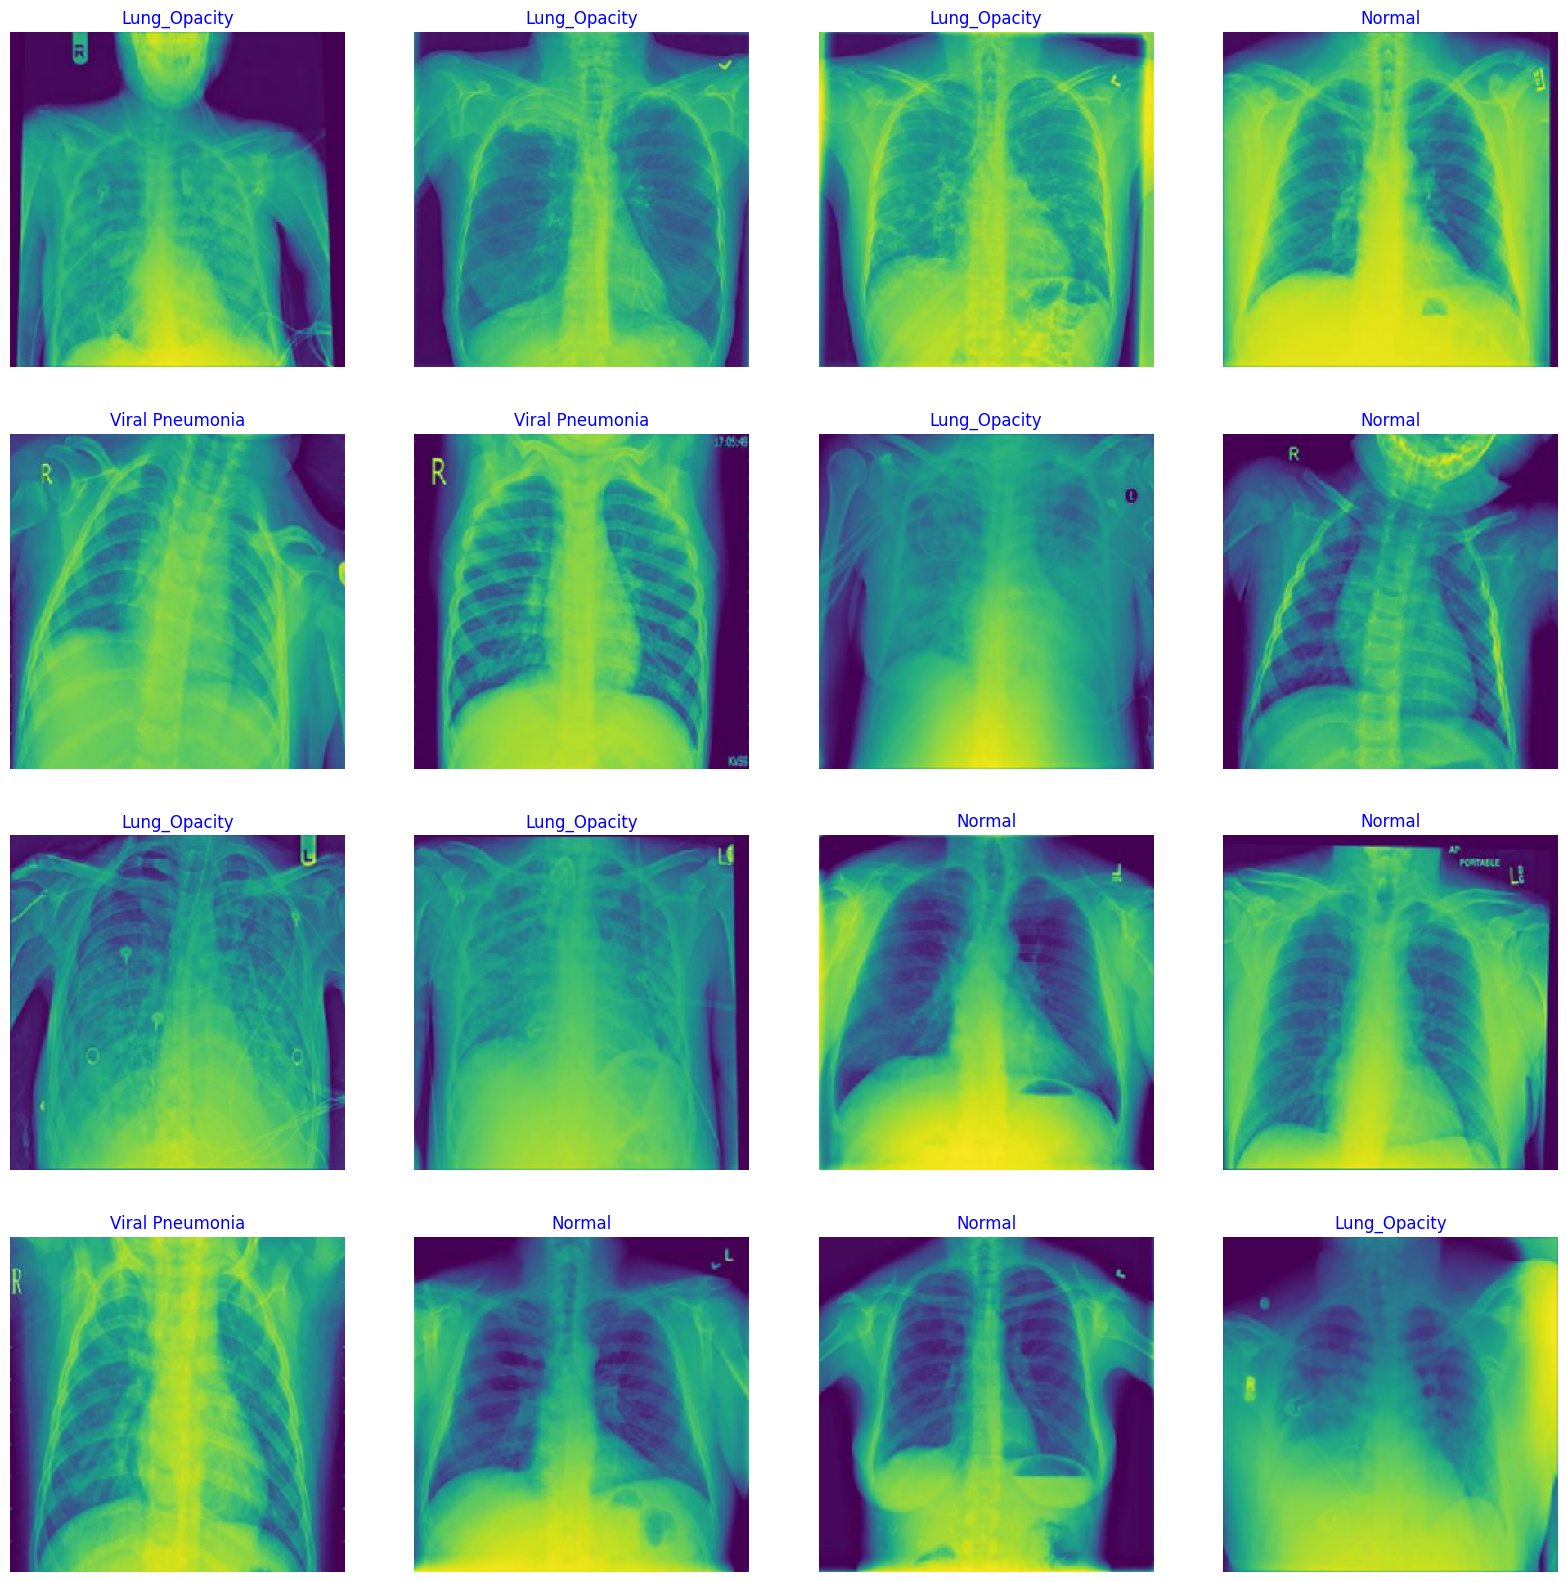

In [6]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

In [7]:
#models
from tensorflow import keras
from keras.applications import EfficientNetB0

In [8]:
IMG_SHAPE=(224,224,3)
base_model   = EfficientNetB0(input_shape=IMG_SHAPE,include_top=False)
print("EfficientNetB0.layers", len(base_model.layers)) #155

#Freeze the convolutional base
for layer in base_model.layers[:100]:
    layer.trainable = False

I0000 00:00:1780740745.768835      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0.layers 238


In [9]:
from tensorflow.keras import layers, models

def Create_model(base_model, num_classes=3):  # 4 classes
    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(1024, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    # Multi-class output
    predictions = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=base_model.input, outputs=predictions)
    return model

In [10]:
model_EfficientNetB0= Create_model(base_model)
model_EfficientNetB0.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,364,390 (20.46 MB)

 Trainable params: 5,155,167 (19.67 MB)

 Non-trainable params: 209,223 (817.28 KB)

In [11]:
class_mode="categorical"
model_EfficientNetB0.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
model_EfficientNetB0.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [14]:
batch_size = 16 
epochs = 10   

history = model_EfficientNetB0.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, 
                    validation_steps= None, shuffle= False)

Epoch 1/10


I0000 00:00:1780740772.837844      69 service.cc:152] XLA service 0x7a1300001fe0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780740772.837902      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780740776.356557      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-06 10:13:03.053658: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:03.238530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:03.677708: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accur

173/174 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8175 - loss: 0.4367

2026-06-06 10:13:40.854642: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:41.039360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:41.459241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:41.663940: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-06 10:13:42.003567: E external/local_xla/xla/stream_

174/174 ━━━━━━━━━━━━━━━━━━━━ 97s 294ms/step - accuracy: 0.8182 - loss: 0.4353 - val_accuracy: 0.9065 - val_loss: 0.2511
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.9285 - loss: 0.1760 - val_accuracy: 0.9376 - val_loss: 0.1932
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - accuracy: 0.9722 - loss: 0.0854 - val_accuracy: 0.9448 - val_loss: 0.1817
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9811 - loss: 0.0486 - val_accuracy: 0.9448 - val_loss: 0.2419
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9847 - loss: 0.0447 - val_accuracy: 0.9448 - val_loss: 0.2164
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.9909 - loss: 0.0327 - val_accuracy: 0.9305 - val_loss: 0.2503
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9902 - loss: 0.0287 - val_accuracy: 0.9305 - val_loss: 0.3121
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9900 - loss: 0.0254 - val_accuracy: 0.9

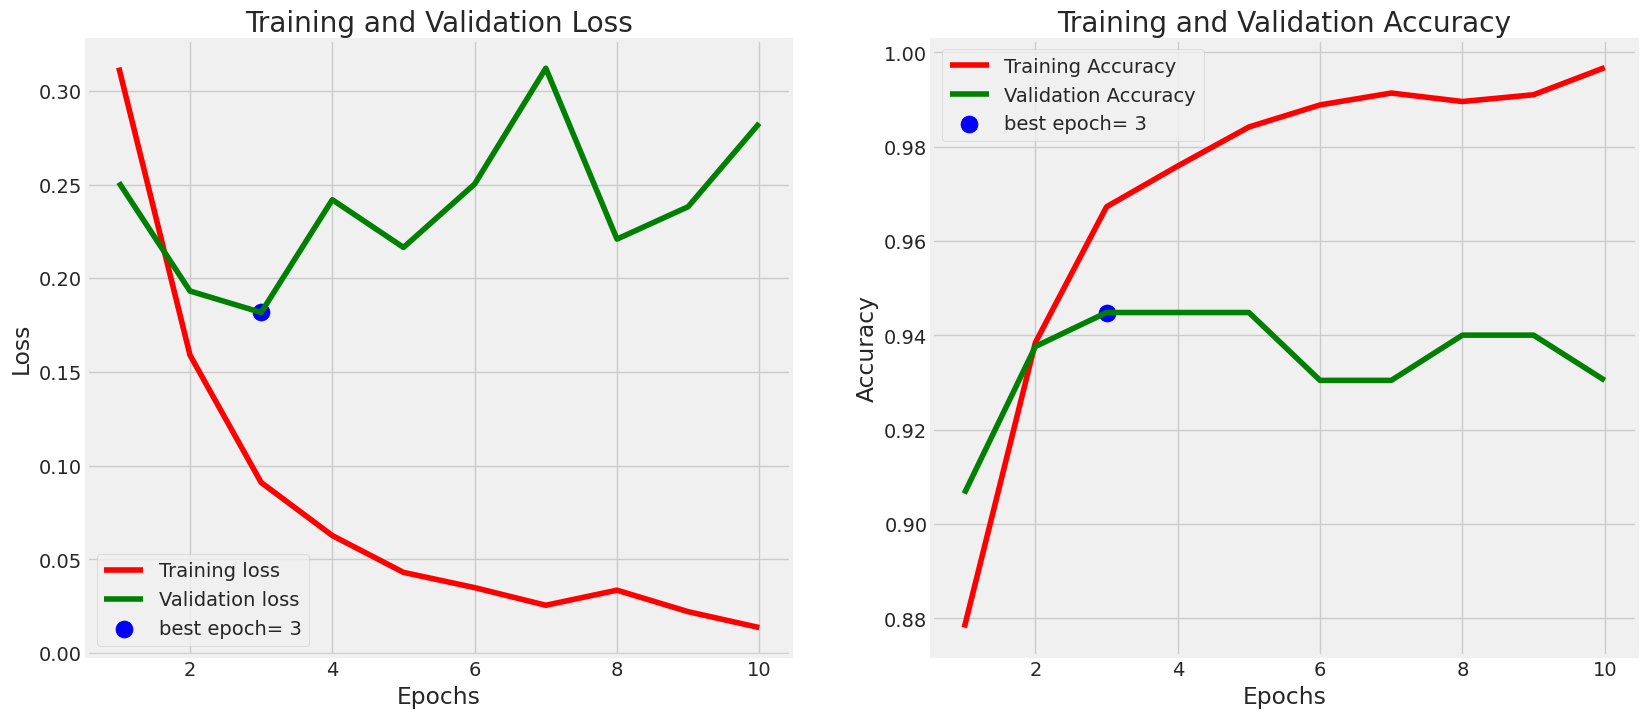

In [15]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [16]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_EfficientNetB0.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = model_EfficientNetB0.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = model_EfficientNetB0.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

139/139 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 1.0000 - loss: 6.7463e-04
139/139 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9281 - loss: 0.2986 
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.9463 - loss: 0.2634
Train Loss:  0.0006882494781166315
Train Accuracy:  1.0
--------------------
Validation Loss:  0.2827063202857971
Validation Accuracy:  0.9304556250572205
--------------------
Test Loss:  0.298117995262146
Test Accuracy:  0.9460431933403015


In [17]:
preds =model_EfficientNetB0.predict(test_gen)
y_pred = np.argmax(preds, axis=1)

139/139 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step


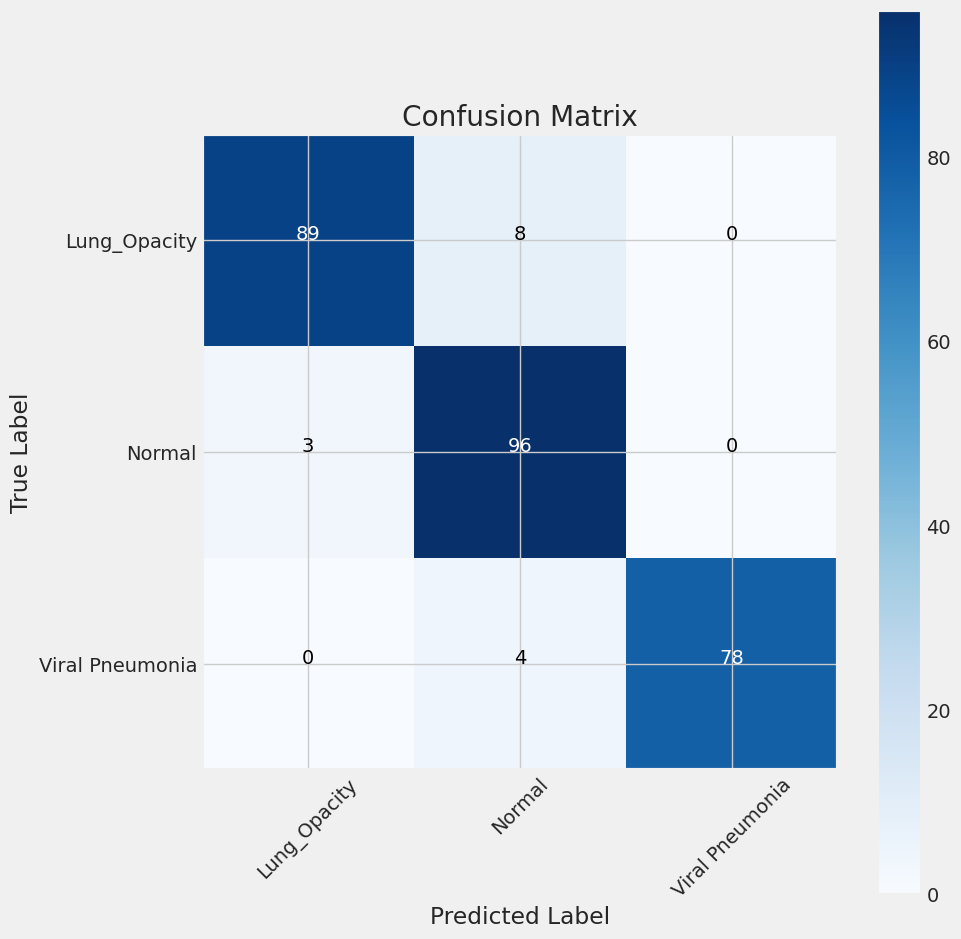

In [18]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [19]:
print(classification_report(test_gen.classes, y_pred, target_names= classes))

                 precision    recall  f1-score   support

   Lung_Opacity       0.97      0.92      0.94        97
         Normal       0.89      0.97      0.93        99
Viral Pneumonia       1.00      0.95      0.97        82

       accuracy                           0.95       278
      macro avg       0.95      0.95      0.95       278
   weighted avg       0.95      0.95      0.95       278



In [20]:
# Save the model
model_EfficientNetB0.save('pneumonia_classifier.keras')

In [21]:
# Load the model
loaded_model = tf.keras.models.load_model(
    '/kaggle/working/pneumonia_classifier.keras',
    compile=False
)

loaded_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Image path
image_path = '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Viral Pneumonia/1005.jpg'

# Open image
image = Image.open(image_path)

# Preprocess image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

# Prediction
predictions = loaded_model.predict(img_array)

class_labels = ['Lung_Opacity', 'Normal', 'Viral Pneumonia']

predicted_class = class_labels[np.argmax(predictions)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted Class: Viral Pneumonia


In [22]:
# Load the model
loaded_model = tf.keras.models.load_model(
    '/kaggle/working/pneumonia_classifier.keras',
    compile=False
)

loaded_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Image path
image_path = '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Normal/1004.jpg'

# Open image
image = Image.open(image_path)

# Preprocess image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

# Prediction
predictions = loaded_model.predict(img_array)

class_labels = ['Lung_Opacity', 'Normal', 'Viral Pneumonia']

predicted_class = class_labels[np.argmax(predictions)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted Class: Normal


In [23]:
# Load the model
loaded_model = tf.keras.models.load_model(
    '/kaggle/working/pneumonia_classifier.keras',
    compile=False
)

loaded_model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Image path
image_path = '/kaggle/input/datasets/fatemehmehrparvar/lung-disease/Lung X-Ray Image/Lung X-Ray Image/Lung_Opacity/1002.jpg'

# Open image
image = Image.open(image_path)

# Preprocess image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)

# Prediction
predictions = loaded_model.predict(img_array)

class_labels = ['Lung_Opacity', 'Normal', 'Viral Pneumonia']

predicted_class = class_labels[np.argmax(predictions)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
Predicted Class: Lung_Opacity
